# M2 – BQ1: Structural Similarity and Latent Regulatory Risk


## Objective

The objective of this analysis is to explore whether withdrawn or refused medicines occupy
distinct or dense regions of the therapeutic similarity space compared to authorized medicines.
This analysis focuses on uncovering latent structural patterns using unsupervised and
unstructured methods, rather than building a predictive or classification model.


In [11]:
import pandas as pd

df = pd.read_csv("Medicines_output_european_public_assessment_reports - Medicines_output_european_public_assessment_reports.csv")

df.head()
df.columns


Index(['Category', 'Medicine name', 'Therapeutic area',
       'International non-proprietary name (INN) / common name',
       'Active substance', 'Product number', 'Patient safety',
       'Authorisation status', 'ATC code', 'Additional monitoring', 'Generic',
       'Biosimilar', 'Conditional approval', 'Exceptional circumstances',
       'Accelerated assessment', 'Orphan medicine',
       'Marketing authorisation date',
       'Date of refusal of marketing authorisation',
       'Marketing authorisation holder/company name',
       'Human pharmacotherapeutic group', 'Vet pharmacotherapeutic group',
       'Date of opinion', 'Decision date', 'Revision number',
       'Condition / indication', 'Species', 'ATCvet code', 'First published',
       'Revision date', 'URL'],
      dtype='object')

## Data and Representation

The analysis uses the European Medicines Agency (EMA) medicines dataset, focusing on the
unstructured textual descriptions of medical indications. Regulatory outcomes
(Authorised, Withdrawn, Refused) are not used to construct the similarity space and are
only applied post-hoc for interpretation.

Therapeutic indication text is chosen as the primary representation due to its richness
and its ability to capture clinical and therapeutic context beyond categorical labels.


In [12]:
df = df[df["Condition / indication"].notna()]

df["Authorisation status"].value_counts()


,count
Authorisation status,
Authorised,1572
Withdrawn,357
Refused,47


In [13]:
df["is_withdrawn"] = df["Authorisation status"].isin(
    ["Withdrawn", "Refused"]
)


## Methodology

This analysis employs unsupervised learning techniques to explore latent similarity:

- TF-IDF is used to transform therapeutic indication text into a numerical feature space.
- Cosine similarity is computed to measure structural proximity between medicines.
- Regulatory outcomes are excluded from model construction and used only for
  interpretive comparison.
- Dimensionality reduction (PCA) is optionally applied for visualization of the similarity space.

These methods are appropriate given the absence of reliable labels and the rarity of
regulatory failure events.


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.8
)

X = tfidf.fit_transform(df["Condition / indication"])


## Analysis Focus

Rather than attempting global clustering, this analysis emphasizes local similarity
neighborhoods around withdrawn or refused medicines. The goal is to assess whether
authorized medicines exist in close proximity to known regulatory failures in the
therapeutic similarity space.


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(X)


In [16]:
withdrawn_idx = df[df["is_withdrawn"]].index[:5]


In [17]:
for idx in withdrawn_idx:
    sims = similarity[idx]
    top = sims.argsort()[-11:-1][::-1]  # exclude self

    print("\nWithdrawn medicine:", df.loc[idx, "Medicine name"])
    print("Most similar authorised medicines:")

    for j in top:
        if not df.loc[j, "is_withdrawn"]:
            print(" -", df.loc[j, "Medicine name"])



Withdrawn medicine: Temozolomide Sandoz
Most similar authorised medicines:
 - NovoThirteen
 - Purevax RC
 - Purevax FeLV
 - Temodal
 - Blenrep
 - Lokelma
 - Quadrisol
 - Ultifend ND IBD

Withdrawn medicine: Hepsera
Most similar authorised medicines:
 - Ganirelix Gedeon Richter
 - INOmax
 - Adynovi
 - Alkindi
 - Entecavir Mylan
 - Zubsolv
 - Viread
 - Nepexto
 - Fortacin
 - Tegsedi

Withdrawn medicine: Kogenate Bayer
Most similar authorised medicines:
 - Olazax Disperzi
 - Advate
 - Triumeq
 - Ongentys
 - Evotaz
 - Esperoct
 - Veyvondi
 - Ziextenzo
 - Orfadin
 - Pradaxa

Withdrawn medicine: Temozolomide Hexal
Most similar authorised medicines:
 - NovoThirteen
 - Purevax RC
 - Purevax FeLV
 - Temodal
 - Blenrep
 - Lokelma
 - Quadrisol
 - Ultifend ND IBD

Withdrawn medicine: Darunavir Krka d.d.
Most similar authorised medicines:
 - Darunavir Krka
 - Kymriah
 - Prezista
 - Tybost
 - Relistor
 - Kivexa
 - Rezolsta
 - Perjeta
 - Epivir


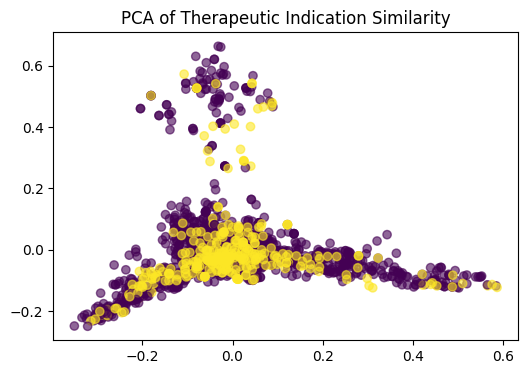

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(6,4))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["is_withdrawn"],
    alpha=0.6
)
plt.title("PCA of Therapeutic Indication Similarity")
plt.show()


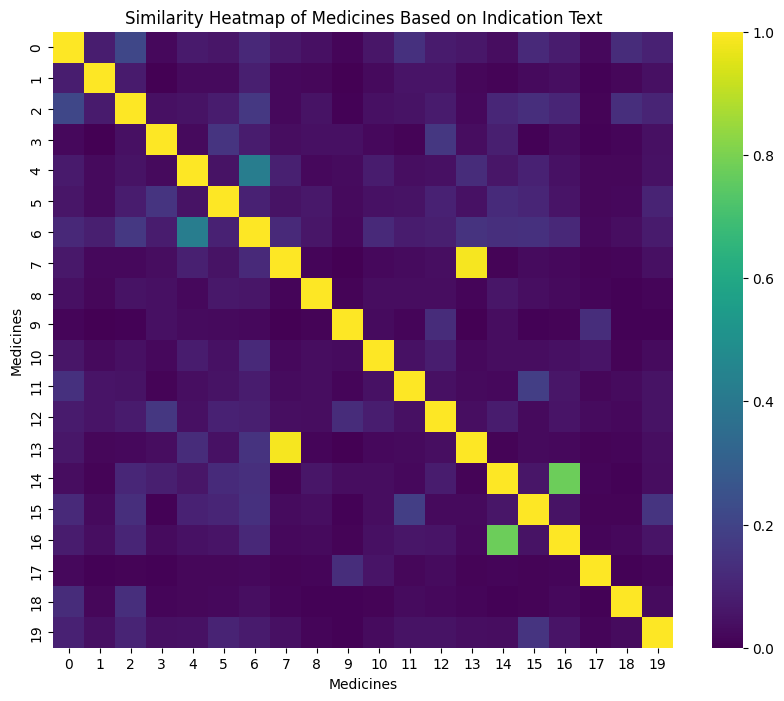

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize a small subset for readability
subset_size = 20
similarity_subset = similarity[:subset_size, :subset_size]

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_subset, cmap="viridis")
plt.title("Similarity Heatmap of Medicines Based on Indication Text")
plt.xlabel("Medicines")
plt.ylabel("Medicines")
plt.show()


### Figure A1: Similarity Heatmap of Medicines Based on Therapeutic Indication Text

Darker values indicate higher similarity. The visualization shows localized
similarity structure without clear global separation between approved and
withdrawn medicines.

## Exploratory Clustering Attempts (Abandoned)

Preliminary unsupervised clustering was explored on the similarity-based representations to
assess whether withdrawn or refused medicines formed globally separable groups. These
attempts proved unstable and highly sensitive to representation choices and parameter
settings. Withdrawn medicines did not consistently form coherent clusters and often appeared
embedded among authorized medicines. As a result, clustering was not pursued further, and
the analysis focused on local similarity neighborhoods instead.


## What Worked and What Did Not

Local similarity analysis revealed meaningful structure in some cases, where withdrawn
medicines shared close proximity with authorized medicines in the similarity space.
However, global clustering approaches were unstable and highly sensitive to representation
choices.

The results indicate that regulatory failure is not uniformly distributed, but the strength
of similarity-based signals varies substantially across medicines.


## Key Observations

- Some withdrawn or refused medicines are embedded within dense regions of authorized
  medicines, suggesting latent regulatory risk not captured by approval status alone.
- Other withdrawn medicines appear isolated, indicating heterogeneity in regulatory
  failure mechanisms.
- Similarity structure is more informative at a local level than at a global clustering level.


## Limitations

This analysis is exploratory and relies solely on textual indication data. Similarity
relationships are sensitive to representation choices, and no causal interpretations are
made. These findings should be viewed as early signals rather than definitive conclusions.


## Next Steps

Future work will focus on refining similarity representations, incorporating additional
structural features, and evaluating the stability of similarity neighborhoods. These steps
will help assess whether latent regulatory risk patterns persist under alternative
representations and analytical choices.
